# Optimisation de la répartition du stockage par batterie pour l'arbitrage d'énergie et l'écrêtage des pointes

## Synthèse

Un site commercial raccordé au réseau exploite une batterie lithium-ion de 2 MW / 8 MWh aux côtés d'une charge électrique comptée. Le site est facturé de deux façons : un **prix de l'énergie** horaire en marché infrajournalier ($/MWh) et une **prime de puissance** mensuelle sur son intervalle d'importation réseau le plus élevé ($/MW). Le gestionnaire d'actif doit décider, heure par heure, quand charger la batterie (achat d'énergie bon marché et hausse du soutirage réseau) et quand la décharger (compensation de l'énergie coûteuse et baisse du soutirage réseau). Deux sources de valeur s'affrontent : l'**arbitrage d'énergie** (acheter bon marché la nuit, décharger à la pointe du soir) et l'**écrêtage des pointes** (plafonner le maximum réseau facturé). La charge n'est pas gratuite — le rendement aller-retour signifie qu'environ 10 % de l'énergie stockée est perdue — de sorte que la planification est une véritable optimisation, pas une heuristique.

Ce notebook construit la décision de bout en bout. Il synthétise d'abord une courbe de prix infrajournalier réaliste sur 24 heures (avec des pointes du matin et du soir plus un creux nocturne) et un profil de charge du site corrélé, puis dresse le profil des deux avec **PROC MEANS** et une plage robuste de centiles 2,5/97,5 des prix via **PROC UNIVARIATE**. Le cœur est un programme linéaire dans **PROC OPTMODEL** : des variables de décision pour la charge, la décharge et l'état de charge horaires, plus une variable de pointe facturée, sujettes à un bilan cumulatif d'état de charge (avec rendement de charge/décharge distinct), des limites de puissance et de capacité, et une contrainte de définition de la pointe. L'objectif maximise la marge d'arbitrage nette de la prime de puissance. **PROC SQL** quantifie ensuite le coût de référence par rapport au coût optimisé, et trois panneaux **PROC SGPLOT** visualisent le programme de charge/décharge par rapport au prix, la trajectoire de l'état de charge et le profil d'importation réseau aplati.

**Résultat sur la journée synthétique :** l'optimiseur remplit la batterie durant les heures nocturnes les moins chères, décharge dans les pointes de prix du matin et du soir, recharge dans le creux de prix de mi-journée et — surtout — retient sa puissance de charge pour ne jamais créer de nouvelle pointe réseau. Le coût quotidien de l'énergie passe de **\$2 903,78 à \$2 528,43** — **\$375,34 (12,9 %) d'économies d'arbitrage** — tandis que le maximum réseau facturé chute de **3,59 MW à 3,43 MW** (environ **0,16 MW**), valant **\$18,98** supplémentaires à la prime de puissance quotidienne supposée. Le même modèle s'applique à des horizons plus longs, à plusieurs scénarios de prix ou à un cyclage tenant compte de la dégradation, simplement en étendant l'ensemble d'indices et les contraintes.

## Sources de données

Toutes les données sont **synthétiques**, générées en ligne dans la première cellule de code avec `CALL STREAMINIT(20260605)` pour la reproductibilité. Aucun fichier externe ni accès réseau. Un seul jeu de données, `price_load`, avec 24 lignes horaires représentant une seule journée d'exploitation.

| Variable | Type | Unités | Description |
|----------|------|-------|-------------|
| `hour` | num | 0–23 | Heure de la journée d'exploitation (indice d'horizon) |
| `price` | num | $/MWh | Prix de l'énergie infrajournalier : creux nocturne, pointes du matin + du soir, avec bruit gaussien (plancher à 5 $) |
| `load` | num | MW | Demande électrique du site, corrélée à l'activité quotidienne (plancher à 0,3 MW) |
| `day_type` | char | — | Indicateur de fenêtre tarifaire : `PeakTOU` (heures 17–21) vs `OffPeak`, utilisé pour le résumé de l'écart de prix pointe/hors-pointe |

Les paramètres de la batterie sont des constantes fixes du modèle à l'intérieur de PROC OPTMODEL : 8 MWh de capacité utile, 2 MW de puissance maximale de charge/décharge, 0,95 de rendement de charge et 0,95 de rendement de décharge (~90 % aller-retour), état de charge initial de 0 MWh, et une prime de puissance de \$120/MW appliquée à la pointe réseau facturée de la journée (la part quotidiennement amortie d'une prime de puissance mensuelle).

# Optimisation de la répartition du stockage par batterie
## Arbitrage d'énergie et écrêtage des pointes pour un site raccordé au réseau

Un site commercial exploite une **batterie de 2 MW / 8 MWh** derrière son compteur. Sa facture d'électricité comporte deux parties : un **prix de l'énergie** horaire ($/MWh) et une **prime de puissance** mensuelle sur le seul intervalle d'importation réseau le plus élevé ($/MW). L'exploitant veut un programme horaire de charge/décharge qui capte deux sources de valeur à la fois :

- **Arbitrage** — stocker l'énergie nocturne bon marché, la restituer durant les heures de pointe coûteuses.
- **Écrêtage des pointes** — décharger durant le pic de demande pour abaisser le maximum réseau facturé.

Parce que le rendement aller-retour perd ~10 % de l'énergie stockée, l'arbitrage est non trivial et justifie une véritable optimisation. Nous la formulons comme un programme linéaire dans **PROC OPTMODEL**, puis quantifions et visualisons le résultat.

> Toutes les données ci-dessous sont synthétiques et générées en ligne — le notebook est entièrement autonome et s'exécute en quelques secondes.

## 1. Générer un profil synthétique de prix infrajournalier et de charge

Nous construisons une journée d'exploitation (24 lignes horaires). La courbe de prix présente un creux nocturne et des pointes du matin + du soir ; la charge du site est corrélée à l'activité quotidienne. Une graine fixe rend l'exécution reproductible. Nous marquons aussi la fenêtre de pointe tarifaire réglementaire (heure d'usage) pour pouvoir résumer l'écart pointe/hors-pointe plus tard.

In [1]:
DONNÉES price_load;
    APPELER streaminit(20260605);
    LONGUEUR day_type $11;
    FAIRE hour = 0 JUSQU_À 23;
        /* Diurnal energy price ($/MWh): morning + evening peaks */
        BASE = 38
             + 26 * EXP(-((hour - 8)**2) / 6)
             + 40 * EXP(-((hour - 19)**2) / 5)
             - 14 * EXP(-((hour - 3)**2) / 8);
        price = round(BASE + rand('normal', 0, 4), 0.01);
        SI price < 5 ALORS price = 5;

        /* Site load (MW): overnight trough, evening ramp */
        LOAD = round(2.0
             + 1.6 * EXP(-((hour - 19)**2) / 7)
             + 0.7 * EXP(-((hour - 9)**2) / 10)
             + rand('normal', 0, 0.10), 0.01);
        SI LOAD < 0.3 ALORS LOAD = 0.3;

        SI hour >= 17 AND hour <= 21 ALORS day_type = 'Pointe';
        SINON day_type = 'Hors-pointe';
        SORTIE;
    FIN;
    SUPPRIMER BASE;
EXÉCUTER;


NOTE: DATA price_load


NOTE: Wrote price_load (24 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## 2. Profil des distributions de prix et de charge

Avant d'optimiser, nous vérifions la cohérence des intrants. L'écart entre les heures les moins chères et les plus chères est ce que l'arbitrage monétise, et la charge maximale ancre l'opportunité d'écrêtage des pointes.

In [2]:
PROCÉDURE MOYENNES DONNÉES=price_load n mean std MIN MAX maxdec=2;
    VAR price LOAD;
    ÉTIQUETTE price="Prix ($/MWh)" LOAD="Charge du site (MW)";
    TITRE "Statistiques du prix et de la charge sur 24 heures";
EXÉCUTER;

                                   Statistiques du prix et de la charge sur 24 heures                                   

                                                  The MEANS Procedure

 Variable  Label                      N        Mean     Std Dev     Minimum     Maximum
 --------------------------------------------------------------------------------------
 price     Prix ($/MWh)              24       46.29       15.81       18.57       79.27
 LOAD      Charge du site (MW)       24        2.47        0.48        1.71        3.59
 --------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3. Écart de prix pointe vs hors-pointe

Le regroupement par indicateur d'heure d'usage montre de combien les heures de pointe sont plus riches que la référence hors-pointe — le signal structurel que la batterie exploite.

In [3]:
PROCÉDURE MOYENNES DONNÉES=price_load mean MIN MAX maxdec=2;
    CLASSE day_type;
    VAR price;
    ÉTIQUETTE day_type="Type d'heure" price="Prix ($/MWh)";
    TITRE "Prix moyen par type d'heure (pointe / creux)";
EXÉCUTER;

                                      Prix moyen par type d'heure (pointe / creux)                                      

                                                  The MEANS Procedure

                                        Analysis Variable : price Prix ($/MWh)

                                                  N
                                Type d'heure    Obs       Mean      Minimum      Maximum
                                --------------------------------------------------------
                                Hors-pointe      19      40.46        18.57        54.89
                                Pointe            5      68.45        54.88        79.27
                                --------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 4. Plage de prix robuste (centiles 2,5 / 97,5)

Nous caractérisons les queues de prix avec une plage de centiles 2,5 / 97,5. **PROC UNIVARIATE** avec `PCTLPTS=` calcule proprement des centiles arbitraires, ce qui est le bon outil pour les centiles fractionnaires.

In [4]:
PROCÉDURE UNIVARIÉ DONNÉES=price_load SANS_IMPRESSION;
    VAR price;
    SORTIE out=price_band pctlpts=2.5 97.5 pctlpre=p_;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=price_band noobs ÉTIQUETTE;
    ÉTIQUETTE p_2_5="2,5e centile du prix" p_97_5="97,5e centile du prix";
    TITRE "Bande de prix : centiles 2,5 % et 97,5 %";
EXÉCUTER;

                                        Bande de prix : centiles 2,5 % et 97,5 %                                        

2,5e centile du prix  97,5e centile du prix
               18.57                  79.27




NOTE: PROC UNIVARIATE
NOTE: Output dataset price_band has 1 observations and 2 variables.
NOTE: PROC PRINT data=price_band

NOTE: PROC PRINT completed: 1 observations printed, 2 variables


## 5. L'optimisation de la répartition (programme linéaire)

Nous lisons le prix et la charge horaires dans PROC OPTMODEL et déclarons :

- `chg[h]`, `dis[h]` — puissance horaire de charge / décharge (MW), bornée par la puissance de 2 MW de l'onduleur.
- `soc[h]` — état de charge (MWh), borné par la capacité utile de 8 MWh.
- `peak` — le maximum réseau facturé (MW).

**Contraintes.** `soc_balance` accumule l'énergie nette au fil de chaque heure avec un rendement de charge/décharge distinct (une forme en somme cumulée de la récurrence horaire). `peak_def` force `peak` à dominer l'importation réseau nette de chaque heure, de sorte que le minimiser écrête la prime de puissance.

**Objectif.** Maximiser la marge d'arbitrage — `price × (discharge − charge)` sommée sur la journée — moins la prime de puissance sur la pointe facturée. Nous résolvons comme un PL continu.

In [5]:
PROCÉDURE optmodel;
    DÉFINIR HOURS;
    num price{HOURS};
    num LOAD{HOURS};

    READ DONNÉES price_load VERS HOURS=[hour]
        price=price col=price
        LOAD=LOAD col=LOAD;

    /* Battery: 8 MWh usable, 2 MW power, ~90% round-trip efficiency */
    num capacity   = 8.0;
    num p_max      = 2.0;
    num eta_chg    = 0.95;
    num eta_dis    = 0.95;
    num soc0       = 0.0;
    num dt         = 1.0;
    /* Demand charge applied to this day's billed grid peak ($/MW).
       Commercial demand charges are monthly; 120 is the marginal value of
       shaving today's grid maximum once the monthly charge is amortized to
       the day. It is large enough that the optimizer will hold charging
       power back rather than create a new, higher peak. */
    num demand_chg = 120;

    /* Decision variables (MW charge / discharge, MWh state of charge) */
    VAR chg{HOURS}  >= 0 <= p_max;
    VAR dis{HOURS}  >= 0 <= p_max;
    VAR soc{HOURS}  >= 0 <= capacity;
    VAR peak        >= 0;   /* billed grid peak (MW) for demand charge */

    /* Net grid import after battery action (MW) */
    impvar grid_mw{h DANS HOURS} = LOAD[h] + chg[h] - dis[h];

    /* Cumulative state of charge: energy in less energy out through hour h,
       with charge/discharge efficiency applied. Equivalent to an hourly
       recurrence but stated as a running sum over prior hours. */
    con soc_balance{h DANS HOURS}:
        soc[h] = soc0
                 + sum{k DANS HOURS: k <= h}
                     (eta_chg * chg[k] - dis[k] / eta_dis) * dt;

    /* Peak shaving: billed peak is the max grid import across the day */
    con peak_def{h DANS HOURS}: peak >= grid_mw[h];

    /* Maximize energy-arbitrage margin net of the peak demand charge */
    MAX net_value =
        sum{h DANS HOURS} price[h] * (dis[h] - chg[h]) * dt
        - demand_chg * peak;

    solve WITH lp;

    CRÉER DONNÉES dispatch DEPUIS [hour=HOURS]
        price=price[hour]
        LOAD=LOAD[hour]
        charge_mw=chg[hour]
        discharge_mw=dis[hour]
        soc_mwh=soc[hour]
        grid_mw=grid_mw[hour];
QUIT;

                                        Bande de prix : centiles 2,5 % et 97,5 %                                        


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Maximization
  Objective Function            NET_VALUE
  Objective Type                Linear

  Number of Variables           73
  Bounded Above                 0
  Bounded Below                 1
  Bounded Below and Above       72
  Free                          0
  Fixed                         0

  Number of Constraints         48

                          Solution Summary
  Solver                        LP
  Objective Function            NET_VALUE
  Solution Status               Optimal
  Objective Value               -36.4771665526




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## 6. Le programme horaire optimal

Le tableau résolu montre la charge répartie sur les heures nocturnes et de mi-journée bon marché — modérée à environ 1,0–1,7 MW pour ne jamais fixer de nouvelle pointe réseau — la décharge concentrée dans les pointes de prix du matin et du soir, et l'état de charge traçant un cycle de remplissage-restitution sensé à l'intérieur du plafond de 8 MWh. La colonne `grid_mw` maintient un plafond plat d'environ 3,43 MW à chaque heure de charge, la signature de la contrainte de pointe active.

In [6]:
PROCÉDURE IMPRIMER DONNÉES=dispatch noobs ÉTIQUETTE;
    VAR hour price LOAD charge_mw discharge_mw soc_mwh grid_mw;
    ÉTIQUETTE hour="Heure du jour" price="Prix ($/MWh)" LOAD="Charge du site (MW)"
              charge_mw="Charge batterie (MW)" discharge_mw="Décharge batterie (MW)"
              soc_mwh="État de charge (MWh)" grid_mw="Import réseau (MW)";
    TITRE "Plan de fonctionnement horaire de la batterie";
EXÉCUTER;

                                     Plan de fonctionnement horaire de la batterie                                      

Heure du jour  Prix ($/MWh)  Charge du site (MW)  Charge batterie (MW)   Décharge batterie (MW)   État de charge (MWh)   Import réseau (MW)
            0         29.73                 1.99             1.4418421                        0                1.36975            3.4318421
            1         28.03                 2.16             1.2718421                        0                  2.578            3.4318421
            2         21.87                    2             1.4318421                        0                3.93825            3.4318421
            3         18.57                 1.71             1.7218421                        0                  5.574            3.4318421
            4         27.62                 2.13             1.3018421                        0                6.81075            3.4318421
            5         36.12           


NOTE: PROC PRINT data=dispatch

NOTE: PROC PRINT completed: 24 observations printed, 7 variables


## 7. Indicateurs clés : référence vs optimisé

Nous comparons la référence sans action (payer le prix de la charge brute à chaque heure) à la position réseau optimisée, et rapportons les économies d'arbitrage, la réduction de la pointe facturée et la valeur en dollars de cette réduction à la prime de puissance — les deux leviers qui portent l'analyse de rentabilité.

In [7]:
PROCÉDURE sql;
    CRÉER table kpi COMME
    SÉLECTIONNER
        sum(price * LOAD)                        COMME base_energy_cost,
        sum(price * grid_mw)                     COMME opt_energy_cost,
        sum(price * LOAD) - sum(price * grid_mw) COMME arbitrage_savings,
        MAX(LOAD)                                COMME base_peak_mw,
        MAX(grid_mw)                             COMME opt_peak_mw,
        MAX(LOAD) - MAX(grid_mw)                 COMME peak_reduction_mw,
        120 * (MAX(LOAD) - MAX(grid_mw))         COMME demand_charge_savings
    DEPUIS dispatch;
QUIT;

PROCÉDURE IMPRIMER DONNÉES=kpi noobs ÉTIQUETTE;
    ÉTIQUETTE base_energy_cost="Coût énergie de base"
              opt_energy_cost="Coût énergie optimisé"
              arbitrage_savings="Économies d'arbitrage"
              base_peak_mw="Pic de base (MW)"
              opt_peak_mw="Pic optimisé (MW)"
              peak_reduction_mw="Réduction du pic (MW)"
              demand_charge_savings="Économies sur la prime de puissance";
    TITRE "Indicateurs clés : arbitrage et écrêtage de pointe";
EXÉCUTER;

                                     Plan de fonctionnement horaire de la batterie                                      

                                   Indicateurs clés : arbitrage et écrêtage de pointe                                   

  Coût énergie de base     Coût énergie optimisé   Économies d'arbitrage  Pic de base (MW)   Pic optimisé (MW)   Réduction du pic (MW)   Économies sur la prime de puissance
             2903.7774           2528.4335145526          375.3438854474              3.59           3.4318421               0.1581579                             18.978948




NOTE: PROC SQL 

NOTE: Table kpi created.
NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=kpi

NOTE: PROC PRINT completed: 1 observations printed, 7 variables


## 8. Programme de charge / décharge par rapport au prix

La charge (aiguilles bleues) et la décharge (ligne rouge à marqueurs) partagent l'axe des mégawatts de gauche ; le prix infrajournalier (vert pointillé) se lit à droite. La charge se regroupe dans les heures nocturnes et de mi-journée bon marché, tandis que la décharge se déclenche dans les pointes de prix du matin et du soir — le visuel confirme que l'optimiseur achète bas et vend haut.

                                   Indicateurs clés : arbitrage et écrêtage de pointe                                   




NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


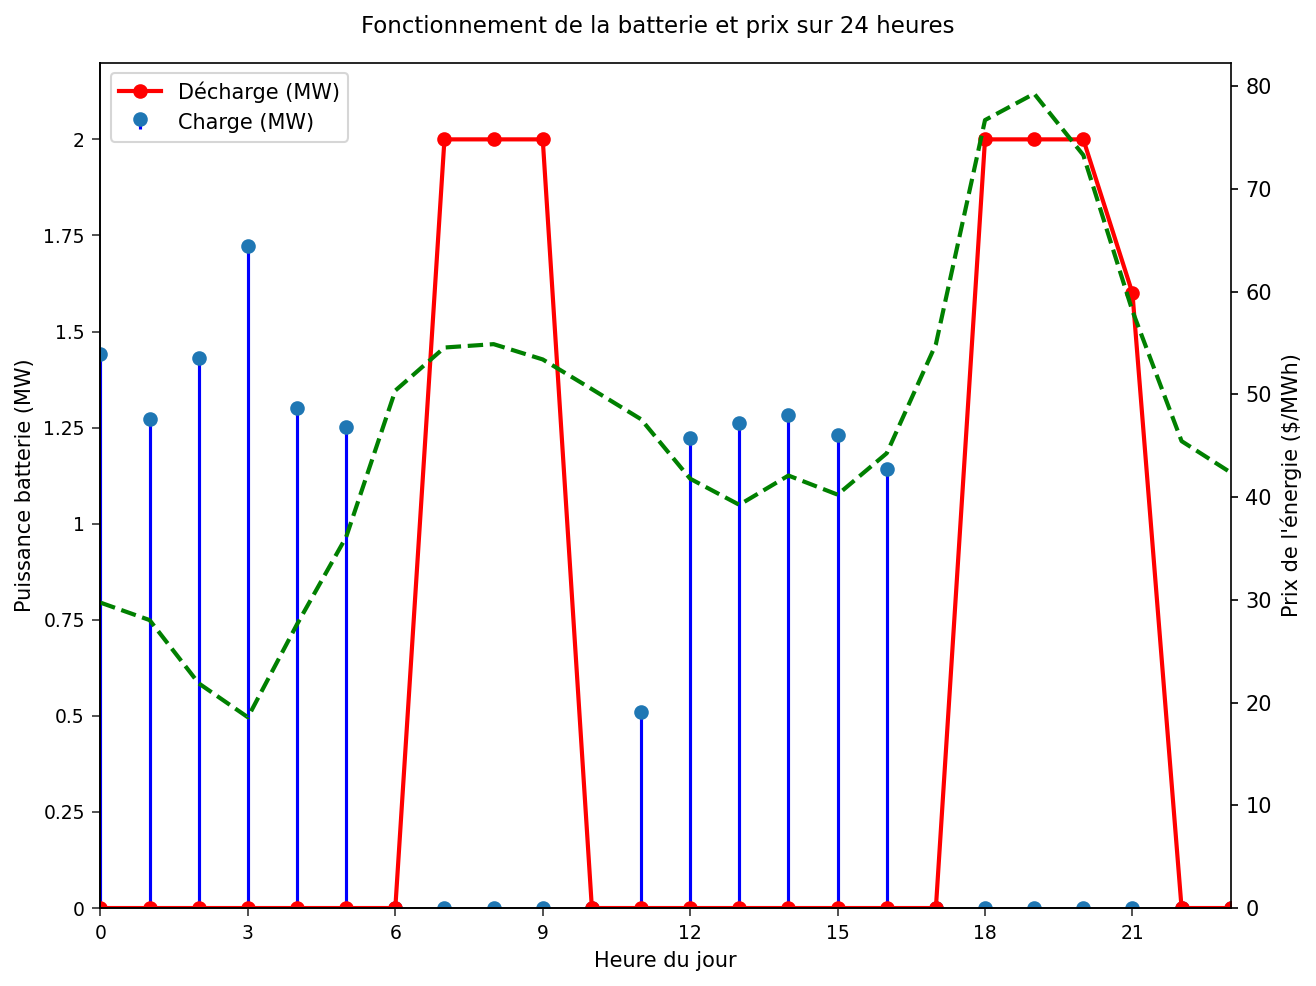

In [8]:
PROCÉDURE SGPLOT DONNÉES=dispatch;
    needle x=hour y=charge_mw / LINEATTRS=(color=blue thickness=3)
        legendlabel="Charge (MW)";
    SERIES x=hour y=discharge_mw / LINEATTRS=(color=red thickness=2)
        MARKERS legendlabel="Décharge (MW)";
    SERIES x=hour y=price / y2axis LINEATTRS=(color=green pattern=dash thickness=2)
        legendlabel="Prix ($/MWh)";
    XAXIS ÉTIQUETTE="Heure du jour" VALUES=(0 JUSQU_À 23 PAR 3);
    YAXIS ÉTIQUETTE="Puissance batterie (MW)" MIN=0 MAX=2.2;
    y2axis ÉTIQUETTE="Prix de l'énergie ($/MWh)" MIN=0;
    TITRE "Fonctionnement de la batterie et prix sur 24 heures";
EXÉCUTER;

## 9. Trajectoire de l'état de charge

L'énergie stockée monte à mesure que la batterie se remplit la nuit, se réduit à chaque fenêtre de décharge et ne franchit jamais le plafond de capacité utile de 8 MWh (référence pointillée).

                                   Indicateurs clés : arbitrage et écrêtage de pointe                                   




NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


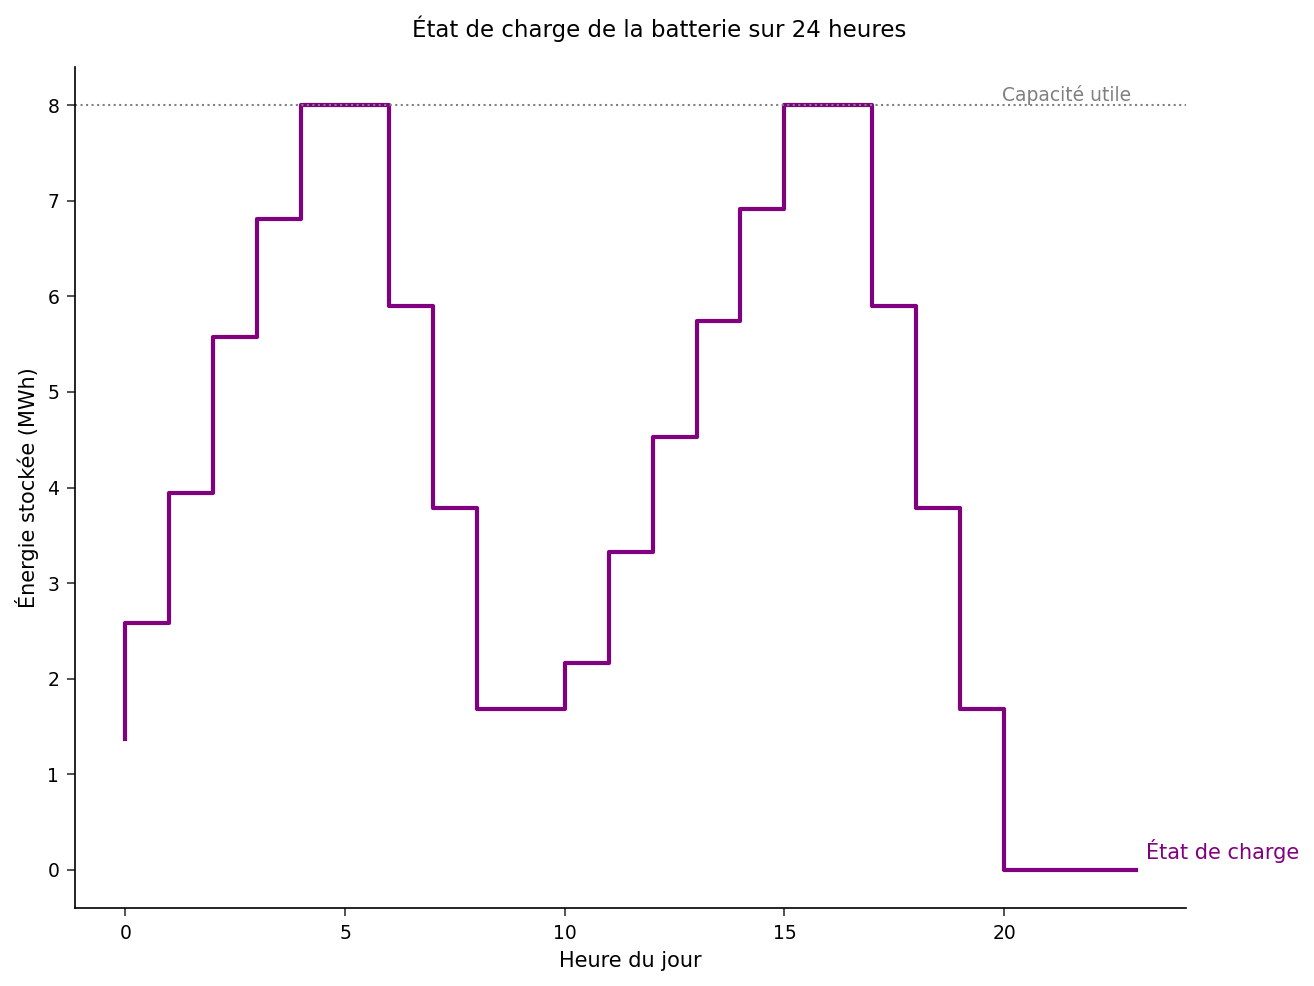

In [9]:
PROCÉDURE SGPLOT DONNÉES=dispatch;
    STEP x=hour y=soc_mwh / LINEATTRS=(color=purple thickness=2)
        curvelabel="État de charge";
    REFLINE 8 / AXIS=y LINEATTRS=(color=grey pattern=dot)
        ÉTIQUETTE="Capacité utile";
    XAXIS ÉTIQUETTE="Heure du jour";
    YAXIS ÉTIQUETTE="Énergie stockée (MWh)";
    TITRE "État de charge de la batterie sur 24 heures";
EXÉCUTER;

## 10. Importation réseau : avant vs après répartition

La ligne orange (importation réseau avec la batterie) tombe bien en dessous de la charge de référence en pointillés durant la montée du soir (heures 18–21) — l'effet d'écrêtage des pointes qui abaisse la prime de puissance. Durant les fenêtres de charge nocturnes et de mi-journée, elle monte, mais l'optimiseur la plafonne à un niveau plat d'environ 3,43 MW qui reste *sous* la pointe de charge initiale de 3,59 MW, de sorte que la charge achète de l'énergie bon marché sans fixer de nouveau maximum facturé.

                                   Indicateurs clés : arbitrage et écrêtage de pointe                                   




NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


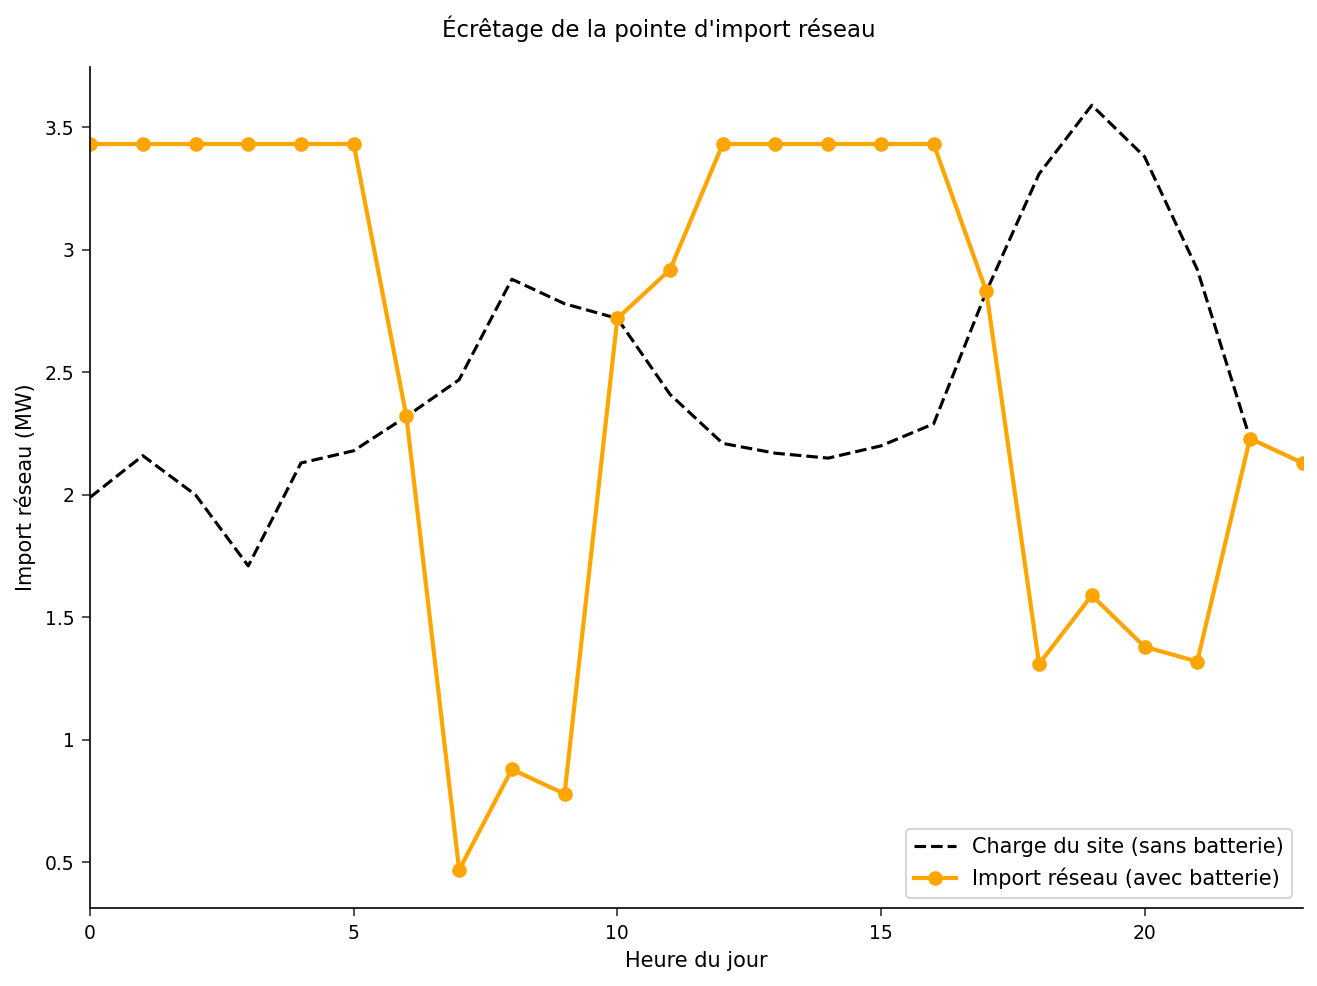

In [10]:
PROCÉDURE SGPLOT DONNÉES=dispatch;
    SERIES x=hour y=LOAD / LINEATTRS=(color=black pattern=dash)
        legendlabel="Charge du site (sans batterie)";
    SERIES x=hour y=grid_mw / LINEATTRS=(color=orange thickness=2)
        MARKERS legendlabel="Import réseau (avec batterie)";
    XAXIS ÉTIQUETTE="Heure du jour";
    YAXIS ÉTIQUETTE="Import réseau (MW)";
    TITRE "Écrêtage de la pointe d'import réseau";
EXÉCUTER;

## Interprétation et prochaines étapes

**Ce que le modèle a décidé.** Alors que le rendement aller-retour taxe chaque cycle, l'optimiseur a tout de même trouvé une valeur claire : il a rempli la batterie durant les heures nocturnes les moins chères, déchargé dans la pointe de prix du matin (heures 7–9), rechargé dans le creux de prix de mi-journée (heures 11–16) et déchargé de nouveau dans la pointe du soir la plus riche (heures 18–21). Fait révélateur, il a chargé à seulement 1,0–1,7 MW plutôt qu'à la pleine puissance de 2 MW durant le remplissage nocturne — retenant la puissance pour que le soutirage réseau supplémentaire ne pousse jamais l'importation au-dessus de la pointe de charge de la journée. L'état de charge a respecté à la fois la capacité de 8 MWh et la limite de puissance de 2 MW à tout moment.

**L'analyse de rentabilité.** Le coût quotidien de l'énergie est passé de **\$2 903,78 à \$2 528,43** — **\$375,34 (12,9 %)** d'économies d'arbitrage — et le maximum réseau facturé a chuté de **3,59 MW à 3,43 MW** (environ **0,16 MW**), retranchant **\$18,98** supplémentaires de la ligne de prime de puissance. Annualisé sur les journées d'exploitation plus la réduction récurrente de la prime de puissance, c'est le type de marge qui finance un investissement en stockage.

**Pourquoi un PL est le bon outil.** Les heuristiques (« charger sous le prix médian, décharger au-dessus ») ignorent les pertes de rendement, le couplage de capacité entre les heures et le fait que la prime de puissance dépend d'un seul intervalle — elles chargeraient à pleine puissance la nuit et *relèveraient* la pointe facturée, détruisant la valeur d'écrêtage. PROC OPTMODEL capture tout cela dans un seul modèle déclaratif et renvoie le programme prouvé optimal, qui ici modère délibérément le taux de charge pour protéger la pointe.

**Étendre le modèle.**

- **Horizons plus longs / multi-jours** — élargir l'ensemble d'indices `HOURS` ; ajouter des limites de cyclage inter-journalier.
- **Incertitude de prix** — résoudre le PL sur plusieurs scénarios de prix et moyenner la décision de la première heure (une politique stochastique glissante).
- **Dégradation de la batterie** — ajouter un terme de pénalité de débit ou une contrainte sur les cycles cumulés pour arbitrer entre l'arbitrage et la durée de vie de l'actif.
- **Réponse en fréquence / marchés de capacité** — introduire des contraintes de réserve de marge pour que la batterie puisse empiler des revenus de services système par-dessus l'arbitrage.

Toutes ces options sont des modifications incrémentales du même bloc OPTMODEL — la structure établie ici se prolonge sans changement.